In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from PIL import Image
from torchvision import models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# If using GPU, check for availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [14]:
# Load MobileNetV2 model
model = models.mobilenet_v2(pretrained=True)
model.to(device)

# Modify the classifier for binary classification
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
# Move all model parameters to the specified device
model = model.to(device)

import torchsummary
# Print the model summary
torchsummary.summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

In [16]:
# You can set the paths to your train and test data folders
train_data_path = "/content/drive/MyDrive/Dataset/DataSet_Malnutrtion/train"
test_data_path = "/content/drive/MyDrive/Dataset/DataSet_Malnutrtion/val"

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the train and test datasets
train_dataset = ImageFolder(train_data_path, transform=transform)
test_dataset = ImageFolder(test_data_path, transform=transform)

# Data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [17]:
# Loss function
criterion = nn.BCELoss()

# Optimizer with Weight decay
# SGD optimizer with momentum and weight decay
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)

# Learning rate scheduling (reduce learning rate on plateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, verbose=True)

# Initialize lists to store training and validation losses and accuracies
training_losses = []
validation_losses = []
training_accuracies = []
validation_accuracies = []

# Define the number of epochs
num_epochs = 50

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels.unsqueeze(1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predicted = (outputs > 0.5).float()
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels.unsqueeze(1)).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = (correct_predictions / total_predictions) * 100

    training_losses.append(epoch_loss)
    training_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_accuracy:.2f}%")

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    validation_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.float().to(device)
            outputs = model(images)
            loss = criterion(outputs, labels.unsqueeze(1))
            validation_loss += loss.item() * images.size(0)

            predicted = (outputs > 0.5).float()
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels.unsqueeze(1)).sum().item()

    avg_val_loss = validation_loss / len(test_loader.dataset)
    validation_losses.append(avg_val_loss)

    # Calculate accuracy for this epoch's validation
    epoch_accuracy = (correct_predictions / total_predictions) * 100
    validation_accuracies.append(epoch_accuracy)

    print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {epoch_accuracy:.2f}%")

    # Adjust learning rate based on validation loss
    scheduler.step(avg_val_loss)

Epoch [1/50], Loss: 0.5288, Training Accuracy: 71.44%
Validation Loss: 0.4698, Validation Accuracy: 73.22%
Epoch [2/50], Loss: 0.3077, Training Accuracy: 88.53%
Validation Loss: 0.2545, Validation Accuracy: 93.22%
Epoch [3/50], Loss: 0.1869, Training Accuracy: 93.80%
Validation Loss: 0.1685, Validation Accuracy: 96.27%
Epoch [4/50], Loss: 0.1190, Training Accuracy: 96.23%
Validation Loss: 0.1381, Validation Accuracy: 95.59%
Epoch [5/50], Loss: 0.0818, Training Accuracy: 97.39%
Validation Loss: 0.1336, Validation Accuracy: 95.25%
Epoch [6/50], Loss: 0.0483, Training Accuracy: 99.02%
Validation Loss: 0.0955, Validation Accuracy: 95.93%
Epoch [7/50], Loss: 0.0381, Training Accuracy: 99.07%
Validation Loss: 0.0754, Validation Accuracy: 97.29%
Epoch [8/50], Loss: 0.0234, Training Accuracy: 99.42%
Validation Loss: 0.0777, Validation Accuracy: 97.29%
Epoch [9/50], Loss: 0.0228, Training Accuracy: 99.42%
Validation Loss: 0.0716, Validation Accuracy: 97.97%
Epoch [10/50], Loss: 0.0161, Training

In [18]:
# Evaluate the model on the test set
model.eval()
true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

# Generate the classification report and confusion matrix
class_names = ['Healthy', 'Unhealthy']
report = classification_report(predicted_labels, true_labels, target_names=class_names)
accuracy = accuracy_score(true_labels, predicted_labels) * 100
print(f"Accuracy: {accuracy:.2f}%")
print(report)

Accuracy: 97.97%
              precision    recall  f1-score   support

     Healthy       0.96      0.99      0.98       122
   Unhealthy       0.99      0.97      0.98       173

    accuracy                           0.98       295
   macro avg       0.98      0.98      0.98       295
weighted avg       0.98      0.98      0.98       295



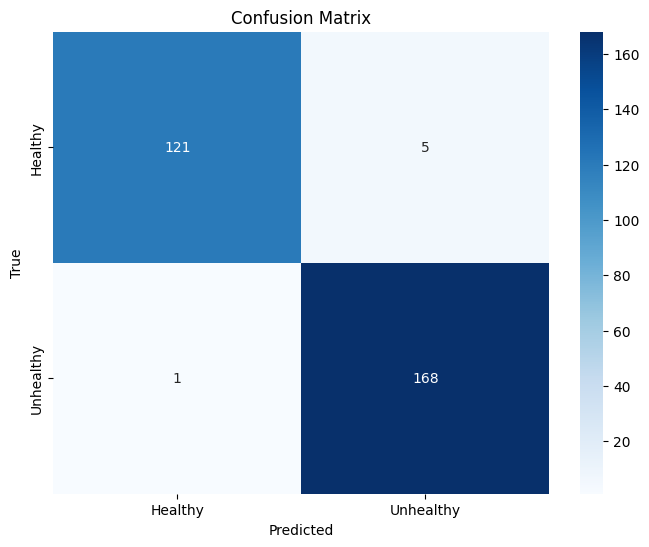

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import numpy as np
# Assuming predicted_labels is a list, convert it to a NumPy array
predicted_labels_np = np.array(predicted_labels)

# Set the threshold for binary classification
threshold = 0.5

# Apply the threshold to convert probabilities to binary predictions
binary_predictions = (predicted_labels_np > threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(true_labels, binary_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

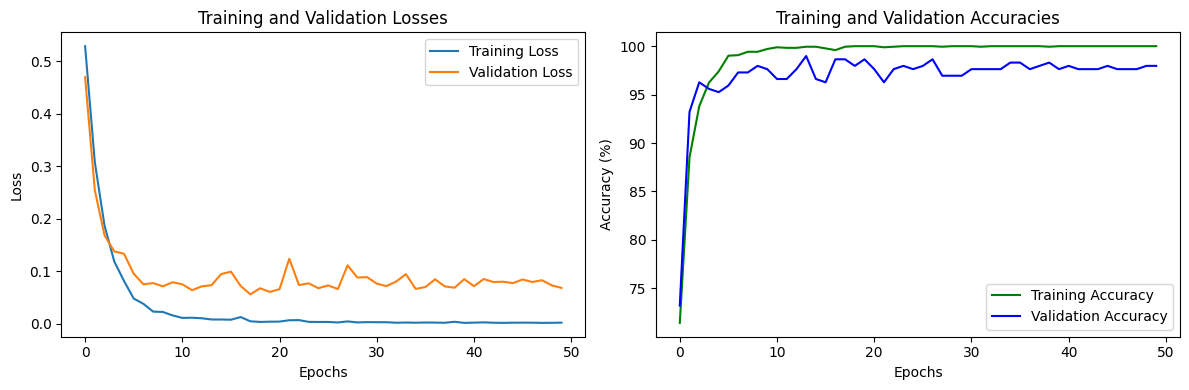

In [20]:
# Plot training and validation losses
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(training_losses, label="Training Loss")
plt.plot(validation_losses, label="Validation Loss")
plt.title("Training and Validation Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_accuracies, label="Training Accuracy", color="green")
plt.plot(validation_accuracies, label="Validation Accuracy", color="blue")
plt.title("Training and Validation Accuracies")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

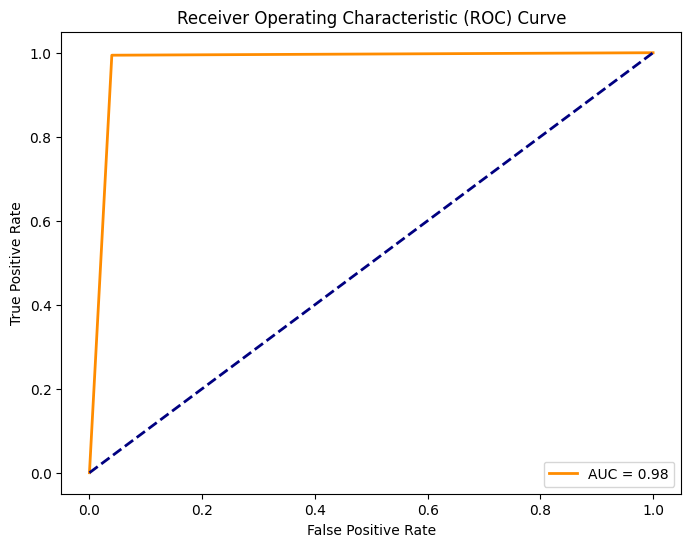

AUC: 0.9772


In [21]:
from sklearn.metrics import roc_curve, auc

# Calculate AUC and plot ROC curve
fpr, tpr, _ = roc_curve(true_labels, predicted_labels)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc:.4f}")